# Portafolio Híbrido: Cripto + Acciones 2026
## Autor: Osman Villanueva García

El siguiente script analiza el rendimiento de 5 criptomonedas y 5 acciones a partir de una matriz conjunta de 10 activos financieros. Se trata de un Portafolio de inversión con posibilidades de obtener un rendimiento anual del 10% en lo que resta del año 2026 (creado con material del Curso del **Dr. Wellcome Peujio** en junio-julio 2026). Al correr el Modelo de Markowitz de forma integrada con datos históricos del presente año, el algoritmo utiliza la baja correlación natural entre la renta variable tradicional y los criptoactivos para encontrar las proporciones matemáticas exactas que minimizan el riesgo global del portafolio.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize

import warnings             # Silenciar advertencias informativas de yfinance y pandas
warnings.filterwarnings('ignore')

print("Configuracion lista.")
print("Bibliotecas instaladas: numpy, pandas, matplotlib, seaborn, yfinance")

Configuracion lista.
Bibliotecas instaladas: numpy, pandas, matplotlib, seaborn, yfinance


## 1. Descarga de Datos con yfinance

Descargamos precios de cierre ajustados del 2026 para 10 activos diversificados:

| Ticker | Nombre / Empresa | Sector |
|---|---|---|
| BTC-USD | Bitcoin | Criptomoneda |
| ETH-USD | Ethereum | Criptomoneda |
| SOL-USD | Solana | Criptomoneda |
| LINK-USD | Chainlink | Criptomoneda |
| XRP-USD | XRP (Ripple) | Criptomoneda |
| NVDA | NVIDIA Corp. | Tecnología (semiconductores) |
| MSFT | Microsoft Corp. | Tecnología (software) |
| AVGO | Broadcom Inc. | Tecnología (semiconductores) |
| LLY | Eli Lilly and Company | Salud (Farmacéutica) |
| WFC | Wells Fargo & Company | Finanzas (Banca) |

##### Nota: Cambia el año o fecha en la línea de código "start=2026-01-01" para realizar el analisis de distintos periódos.

Descargando datos históricos del mercado cruzado (YTD 2026)...


[*********************100%***********************]  10 of 10 completed



⚖️ DISTRIBUCIÓN ÓPTIMA DEL PORTAFOLIO INTEGRADO (MARKOWITZ 2026)
[Cripto] BTC-USD    : Porcentaje de asignación =  10.78%
[Cripto] ETH-USD    : Porcentaje de asignación =   0.00%
[Cripto] SOL-USD    : Porcentaje de asignación =   0.00%
[Cripto] LINK-USD   : Porcentaje de asignación =   0.00%
[Cripto] XRP-USD    : Porcentaje de asignación =  27.49%
[Acción] NVDA       : Porcentaje de asignación =  12.05%
[Acción] MSFT       : Porcentaje de asignación =  15.96%
[Acción] AVGO       : Porcentaje de asignación =   0.00%
[Acción] LLY        : Porcentaje de asignación =  33.72%
[Acción] WFC        : Porcentaje de asignación =   0.00%
----------------------------------------------------------------------
🚀 Rendimiento Anual del Portafolio : 10.00%
📉 Riesgo Mínimo Alcanzado (Volatilidad) : 22.36%


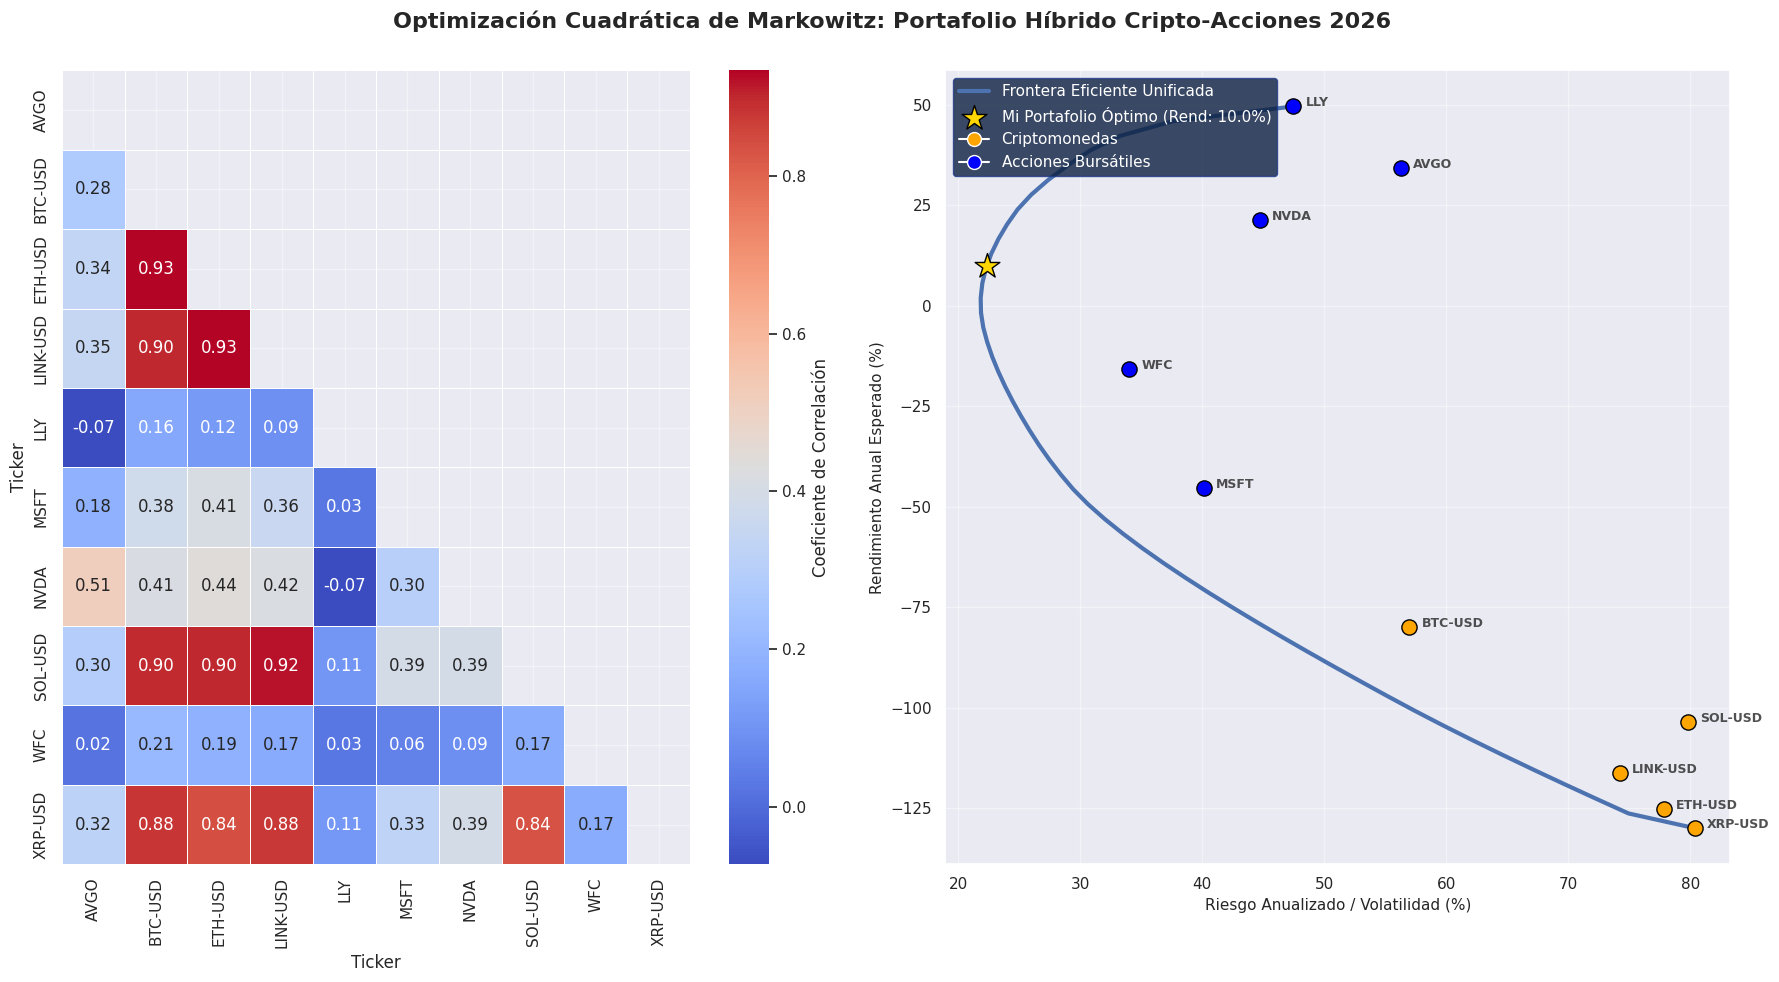

In [46]:
# ==========================================
# 1. Configuración del Portafolio Híbrido (2026)
# ==========================================
criptos = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'LINK-USD', 'XRP-USD']
acciones = ['NVDA', 'MSFT', 'AVGO', 'LLY', 'WFC']
portafolio = criptos + acciones

print("Descargando datos históricos del Portafolio Híbrido (AÑO 2026)...")

# ==========================================
# Descargar la columna 'Close' para evitar problemas de MultiIndex
# ==========================================
data = yf.download(portafolio, start="2026-01-01")
if 'Close' in data.columns.levels[0] if isinstance(data.columns, pd.MultiIndex) else 'Close' in data.columns:
    df = data['Close'].dropna()
else:
# Respaldo en caso de que la estructura sea plana
    df = data.dropna()

# ==========================================
# Calcular rendimientos diarios de mercado
# ==========================================
rendimientos_diarios = df.pct_change().dropna()

# ==========================================
# 2. Homologación Temporal a Periodo anualizado (con 352 para acciones y 365 días cripto)
# ==========================================
DIAS_ANUALES = 365
rend_esperados_anuales = rendimientos_diarios.mean() * DIAS_ANUALES
matriz_covarianza_anual = rendimientos_diarios.cov() * DIAS_ANUALES

RENDIMIENTO_OBJETIVO = 0.10  # 10% objetivo solicitado para el portafolio total

# ==========================================
# 3. Modelado Matemático de Markowitz
# ==========================================
def calcular_rendimiento_portafolio(pesos, rendimientos_esperados):
    return np.sum(rendimientos_esperados * pesos)

def calcular_volatilidad_portafolio(pesos, matriz_cov):
    return np.sqrt(np.dot(pesos.T, np.dot(matriz_cov, pesos)))

def optimizar_portafolio_riesgo_minimo(rendimientos_esperados, matriz_cov, rend_objetivo):
    num_activos = len(rendimientos_esperados)
    pesos_iniciales = num_activos * [1.0 / num_activos]

    restricciones = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'eq', 'fun': lambda w: calcular_rendimiento_portafolio(w, rendimientos_esperados) - rend_objetivo}
    )
    limites = tuple((0.0, 1.0) for _ in range(num_activos))

    resultado = minimize(
        calcular_volatilidad_portafolio,
        pesos_iniciales,
        args=(matriz_cov,),
        method='SLSQP',
        bounds=limites,
        constraints=restricciones
    )
    return resultado

# ==========================================
# Ejecutar optimización numérica cuadrática
# ==========================================
resultado_opt = optimizar_portafolio_riesgo_minimo(rend_esperados_anuales, matriz_covarianza_anual, RENDIMIENTO_OBJETIVO)
pesos_optimos = resultado_opt.x
volatilidad_optima = resultado_opt.fun

# ==========================================
# 4. Informe de Resultados
# ==========================================
print("\n" + "="*70)
print("⚖️ DISTRIBUCIÓN ÓPTIMA DEL PORTAFOLIO INTEGRADO (MARKOWITZ 2026)")
print("="*70)
for i, activo in enumerate(portafolio):
    tipo = "Cripto" if activo in criptos else "Acción"
    print(f"[{tipo:<6}] {activo:<10} : Porcentaje de asignación = {pesos_optimos[i]*100:6.2f}%")
print("-" * 70)
print(f"🚀 Rendimiento Anual del Portafolio : {RENDIMIENTO_OBJETIVO*100:.2f}%")
print(f"📉 Riesgo Mínimo Alcanzado (Volatilidad) : {volatilidad_optima*100:.2f}%")
print("="*70)

# ==========================================
# 5. Generación de Tablero Gráfico
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))
sns.set_theme(style="darkgrid")

# --- GRÁFICO 1: Matriz de Correlación Inter-Mercado ---
matriz_correlacion = rendimientos_diarios.corr()
mask = np.triu(np.ones_like(matriz_correlacion, dtype=bool))

sns.heatmap(matriz_correlacion, mask=mask, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, ax=ax1, cbar_kws={'label': 'Coeficiente de Correlación'})
ax1.set_title("Gráfico 1: Correlación Cruzada (Cripto vs Acciones 2026)", fontsize=13, fontweight='bold')

# --- GRÁFICO 2: Frontera Eficiente Unificada ---
rendimientos_frontera = np.linspace(rend_esperados_anuales.min(), rend_esperados_anuales.max(), 50)
volatilidades_frontera = []

for r_obj in rendimientos_frontera:
    res = optimizar_portafolio_riesgo_minimo(rend_esperados_anuales, matriz_covarianza_anual, r_obj)
    if res.success:
        volatilidades_frontera.append(res.fun)
    else:
        volatilidades_frontera.append(np.nan)

ax2.plot(np.array(volatilidades_frontera)*100, rendimientos_frontera*100, 'b-', linewidth=3, label='Frontera Eficiente Unificada')

# Graficar activos individuales y categorizarlos por colores
for i, activo in enumerate(portafolio):
    color_punto = 'orange' if activo in criptos else 'blue'
    ax2.scatter(np.sqrt(matriz_covarianza_anual.loc[activo, activo])*100, rend_esperados_anuales.loc[activo]*100,
                s=120, color=color_punto, edgecolors='black', zorder=4)
    ax2.text(np.sqrt(matriz_covarianza_anual.loc[activo, activo])*100 + 1, rend_esperados_anuales.loc[activo]*100,
             activo, fontsize=9, fontweight='bold', alpha=0.8)

# Destacar el portafolio óptimo diversificado (Estrella Dorada)
ax2.scatter(volatilidad_optima*100, RENDIMIENTO_OBJETIVO*100, color='gold', marker='*', s=350,
            edgecolors='black', zorder=5, label=f'Mi Portafolio Óptimo (Rend: {RENDIMIENTO_OBJETIVO*100}%)')

ax2.set_title("Gráfico 2: Frontera Eficiente Cruzada y Ubicación de Activos", fontsize=13, fontweight='bold')
ax2.set_xlabel("Riesgo Anualizado / Volatilidad (%)", fontsize=11)
ax2.set_ylabel("Rendimiento Anual Esperado (%)", fontsize=11)

lineas, etiquetas = ax2.get_legend_handles_labels()
leyenda_cripto = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='Criptomonedas')
leyenda_accion = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Acciones Bursátiles')

legend = ax2.legend(handles=lineas + [leyenda_cripto, leyenda_accion], loc="upper left", frameon=True)

# Cambiar color blanco en el texto de la leyenda en gráfico coordenada "ax2"
for text in legend.get_texts():
    text.set_color('white')

plt.suptitle("Optimización Cuadrática de Markowitz: Portafolio Híbrido Cripto-Acciones 2026", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()